# Desafío - Predicción de cancelación de reserva

### 1. Importa las librerías necesarias para aplicar preprocesamiento de datos, visualización y creación de un modelo de red neuronal feedforward con Keras y Tensorflow, además de las librerías para realizar regularización y búsqueda de grilla. 
### Luego, debes descartar las columnas index, arrival_date_year, agent, country, company, reservation_status y reservation_status_date. Revisa después si la base de datos presenta valores ausentes; en el caso que existan deberá eliminar estos registros siempre y cuando la cantidad sea menor al 4% del total. En caso que sea superior debes decidir si quitar la característica o imputar los datos faltantes aplicando alguna estrategía, que debes describir


In [1]:
# Importamos librerías para manipulación de datos
import pandas as pd
import numpy as np

# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos herramientas de preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Importamos métricas de evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score

# Importamos TensorFlow y Keras
import tensorflow as tf
import keras

# Restricciones
from keras.constraints import MaxNorm

# Regularizadores
from keras.regularizers import l1, l2, l1_l2

# Wrapper para GridSearch
from scikeras.wrappers import KerasClassifier

from itertools import product

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam
from keras.initializers import GlorotNormal, GlorotUniform

# Configuramos semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Ignoramos warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Definimos la ruta del archivo CSV
DATA_PATH = 'hotel_bookings.csv'

# Cargamos la base de datos
df = pd.read_csv(DATA_PATH)

# Mostramos las primeras filas
display(df.head())

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


In [3]:
# Mostramos dimensiones del DataFrame
print("Dimensiones del DataFrame:", df.shape)

# Mostramos información general
df.info()

Dimensiones del DataFrame: (119390, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386

In [4]:
# Columnas que el enunciado solicita descartar
columnas_eliminar = [
    'index',
    'arrival_date_year',
    'agent',
    'country',
    'company',
    'reservation_status',
    'reservation_status_date'
]

# Eliminamos columnas si existen en el DataFrame
df_prep = df.drop(columns=columnas_eliminar, errors='ignore')

# Verificamos resultado
print("Dimensiones después de eliminar columnas:", df_prep.shape)
display(df_prep.head())

Dimensiones después de eliminar columnas: (119390, 26)


,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,27,1,0,0,2,0.0,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,27,1,0,0,2,0.0,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,27,1,0,1,1,0.0,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,27,1,0,1,1,0.0,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,27,1,0,2,2,0.0,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


In [5]:
# Tabla de valores ausentes
tabla_nulos = pd.DataFrame({
    'Valores ausentes': df_prep.isnull().sum(),
    'Porcentaje (%)': (df_prep.isnull().mean() * 100).round(4)
})

# Ordenamos de mayor a menor porcentaje
tabla_nulos = tabla_nulos.sort_values(
    by='Porcentaje (%)',
    ascending=False
)
# Mostramos tabla nulos
display(tabla_nulos)

,Valores ausentes,Porcentaje (%)
children,4,0.0034
hotel,0,0.0000
is_canceled,0,0.0000
lead_time,0,0.0000
arrival_date_week_number,0,0.0000
arrival_date_month,0,0.0000
arrival_date_day_of_month,0,0.0000
stays_in_weekend_nights,0,0.0000
stays_in_week_nights,0,0.0000
adults,0,0.0000


In [6]:
# Columnas con valores ausentes
cols_menos_4 = tabla_nulos[
    tabla_nulos['Valores ausentes'] > 0
].index

# Eliminamos filas con nulos
df_prep = df_prep.dropna(subset=cols_menos_4)

# Verificamos nuevamente valores ausentes
tabla_nulos_post = pd.DataFrame({
    'Valores ausentes': df_prep.isnull().sum(),
    'Porcentaje (%)': (df_prep.isnull().mean() * 100).round(4)
})

tabla_nulos_post = tabla_nulos_post.sort_values(
    by='Porcentaje (%)',
    ascending=False
)
# Mostranos tabla despues de limpiar nulos 
display(tabla_nulos_post)

,Valores ausentes,Porcentaje (%)
hotel,0,0.0
is_canceled,0,0.0
lead_time,0,0.0
arrival_date_month,0,0.0
arrival_date_week_number,0,0.0
arrival_date_day_of_month,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0
children,0,0.0


e identificó que la variable children presentaba únicamente 4 valores ausentes (0.0034% del total de observaciones). Dado que el porcentaje de datos faltantes es inferior al 4% establecido en la pauta, se optó por eliminar dichos registros. Tras esta operación, el conjunto de datos quedó libre de valores nulos.

### 2. Realiza un análisis descriptivo y prepara los datos. Para esto:

a. Selecciona 5 variables que consideres relevantes (que no sean la variable adr) con respecto a cancelar una reserva.

b. Construye un histograma para la variable adr con reservas canceladas y no canceladas, y comenta el resultado.

c. Revisa la presencia de outlier para la variable adr. En caso que presente valores extremos indica la cantidad de outliers por arriba, y la cantidad de outlier por abajo. Eliminar sólo los tres valores más extremos en ambos casos, para los demás cambia sus valores por el valor promedio de la variable.

d. Transforma las variables categóricas en variables dummies, estandariza las variables independientes con media igual a cero y desviación estándar 1 y realiza una división de los datos para entrenamiento y test, este último con un 33% de registros.

### Análisis Descriptivo

In [7]:
# Mostramos total de cancelados y no cancelados 
print(df_prep['is_canceled'].value_counts())

print(
    round(
        df_prep['is_canceled'].value_counts(normalize=True)*100,
        2
    )
)

is_canceled
0    75166
1    44220
Name: count, dtype: int64
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


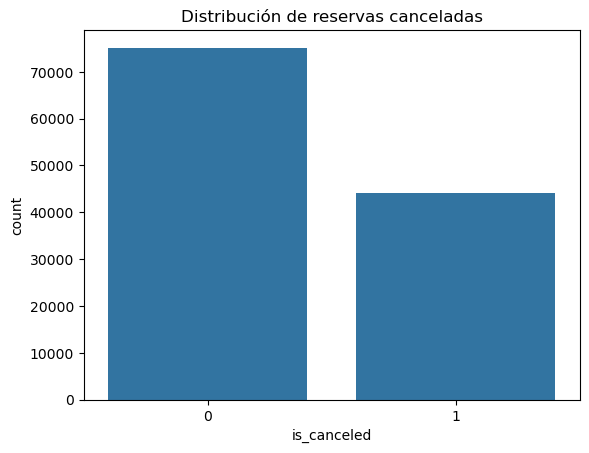

In [8]:
# Mostramos distribucion de cancelados y no cancelados 
sns.countplot(data=df_prep, x='is_canceled')
plt.title('Distribución de reservas canceladas')
plt.show()

La variable objetivo is_canceled presenta una distribución moderadamente desbalanceada, donde el 62.96% de las reservas no fueron canceladas y el 37.04% sí fueron canceladas. A pesar del desbalance, ambas clases cuentan con una cantidad suficiente de observaciones para el entrenamiento de modelos predictivos.

In [9]:
# Mostramos estadistico 
df_prep.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119386.0,0.370395,0.482913,0.00,0.00,0.00,1.0,1.0
lead_time,119386.0,104.014801,106.863286,0.00,18.00,69.00,160.0,737.0
arrival_date_week_number,119386.0,27.165003,13.605334,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119386.0,15.798553,8.780783,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119386.0,0.927605,0.998618,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119386.0,2.500310,1.908289,0.00,1.00,2.00,3.0,50.0
adults,119386.0,1.856390,0.579261,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.00,0.0,10.0
babies,119386.0,0.007949,0.097438,0.00,0.00,0.00,0.0,10.0
is_repeated_guest,119386.0,0.031913,0.175770,0.00,0.00,0.00,0.0,1.0


Las variables numéricas muestran distintos niveles de dispersión. Destacan lead_time y adr, que presentan una gran variabilidad entre reservas, lo que sugiere que podrían aportar información relevante para predecir cancelaciones.

In [10]:
# Analizamos las variables categóricas del conjunto de datos.
# Para cada variable mostramos sus categorías más frecuentes,
# lo que permite identificar patrones, categorías dominantes
# y posibles desbalances en los datos.
for col in df_prep.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df_prep[col].value_counts().head())


hotel
hotel
City Hotel      79326
Resort Hotel    40060
Name: count, dtype: int64

arrival_date_month
arrival_date_month
August     13873
July       12661
May        11791
October    11160
April      11089
Name: count, dtype: int64

meal
meal
BB           92306
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment
market_segment
Online TA        56476
Offline TA/TO    24219
Groups           19811
Direct           12605
Corporate         5295
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        1
Name: count, dtype: int64

reserved_room_type
reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
Name: count, dtype: int64

assigned_room_type
assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
Name: count, dtype: int64

deposit_type
deposit_type
No Deposit    104637
Non Refund 

Las reservas se concentran principalmente en hoteles urbanos, clientes transitorios y reservas realizadas a través de agencias de viaje online. Además, la mayoría de las reservas no exige depósito previo.

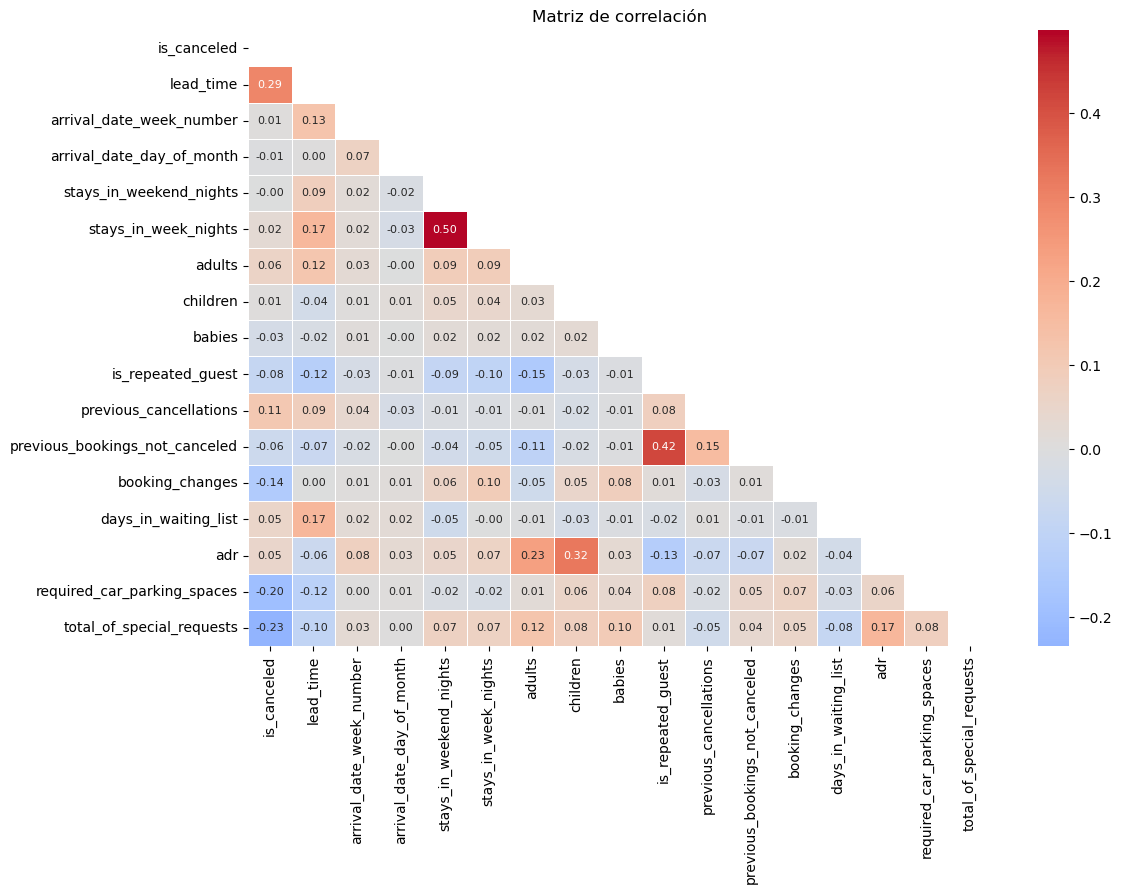

In [11]:
# Calculamos la matriz de correlación
corr = df_prep.select_dtypes(include=np.number).corr()

# Creamos una máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tamaño de figura
plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,      # mostrar valores
    fmt='.2f',       # 2 decimales
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size':8}
)
# Mostramos matriz de correlación
plt.title('Matriz de correlación')
plt.show()

La matriz de correlación muestra asociaciones moderadas entre algunas variables predictoras, destacando stays_in_week_nights y stays_in_weekend_nights (r=0.50), así como previous_bookings_not_canceled e is_repeated_guest (r=0.42). Sin embargo, ninguna correlación supera 0.70, por lo que no se observan problemas significativos de multicolinealidad. Las variables con mayor asociación respecto de la variable objetivo (is_canceled) son lead_time (0.29), total_of_special_requests (-0.23), required_car_parking_spaces (-0.20), booking_changes (-0.14) y previous_cancellations (-0.11).

### a. Selecciona 5 variables que consideres relevantes (que no sean la variable adr) con respecto a cancelar una reserva.

Entonces las 5 variables seleccionadas son:

1. Lead_time → correlación más alta con is_canceled (0.29).
2. Total_of_special_requests → correlación negativa importante (-0.23).
3. Required_car_parking_spaces → correlación negativa relevante (-0.20).
4. Booking_changes → correlación moderada (-0.14).
5. Previous_cancellations → aporta comportamiento histórico del cliente (0.11).

In [12]:
variables_seleccionadas = [
    'lead_time',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'booking_changes',
    'previous_cancellations'
]

### b. Construye un histograma para la variable adr con reservas canceladas y no canceladas, y comenta el resultado.

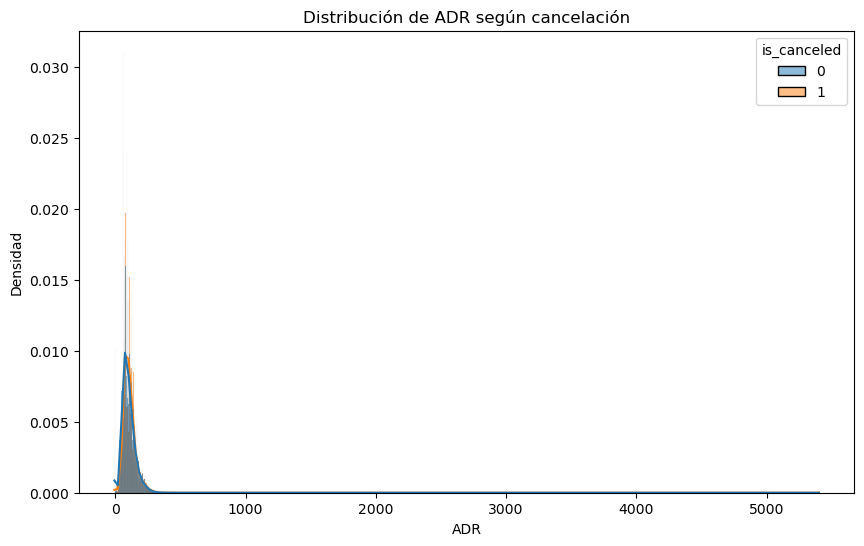

In [13]:
# Mostramos el histograma
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_prep,
    x='adr',
    hue='is_canceled',
    kde=True,
    stat='density',
    common_norm=False
)
plt.title('Distribución de ADR según cancelación')
plt.xlabel('ADR')
plt.ylabel('Densidad')
plt.show()

La variable ADR presenta una distribución fuertemente sesgada a la derecha debido a la presencia de valores extremos. Además, las distribuciones de reservas canceladas y no canceladas muestran un alto grado de solapamiento, por lo que no es posible distinguir claramente ambos grupos utilizando únicamente esta variable. Se observa la necesidad de tratar los valores atípicos antes de realizar análisis más detallados.

### c. Revisa la presencia de outlier para la variable adr. En caso que presente valores extremos indica la cantidad de outliers por arriba, y la cantidad de outlier por abajo. Eliminar sólo los tres valores más extremos en ambos casos, para los demás cambia sus valores por el valor promedio de la variable

Límite inferior: -15.77
Límite superior: 211.06


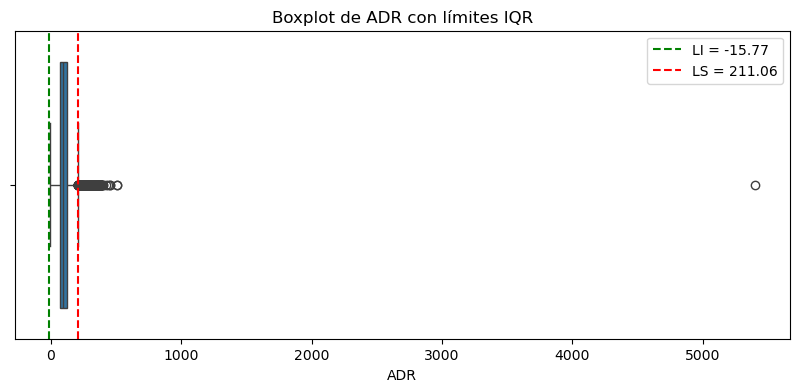

In [14]:
# Revisamos la presencia de valores atípicos (outliers) en la variable ADR
# utilizando el método del rango intercuartílico (IQR).

# Calculamos el primer y tercer cuartil
Q1 = df_prep['adr'].quantile(0.25)
Q3 = df_prep['adr'].quantile(0.75)

# Calculamos el rango intercuartílico
IQR = Q3 - Q1

# Definimos los límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mostramos los límites calculados
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))

# Graficamos un boxplot para visualizar la distribución de ADR
# y detectar posibles valores extremos
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_prep['adr']
)
plt.axvline(
    limite_inferior,
    color='green',
    linestyle='--',
    label=f'LI = {limite_inferior:.2f}'
)
plt.axvline(
    limite_superior,
    color='red',
    linestyle='--',
    label=f'LS = {limite_superior:.2f}'
)
plt.title('Boxplot de ADR con límites IQR')
plt.xlabel('ADR')
plt.legend()
plt.show()

El boxplot de la variable ADR evidencia la presencia de numerosos valores atípicos por encima del límite superior calculado mediante el método IQR. No se observan valores atípicos inferiores.

In [15]:
# Cantidad de outliers
outliers_bajos = df_prep[df_prep['adr'] < limite_inferior]
outliers_altos = df_prep[df_prep['adr'] > limite_superior]

# Mostramos cantidad de outliers
print("Outliers inferiores:", len(outliers_bajos))
print("Outliers superiores:", len(outliers_altos))
print("--- Outliers inferiores: ---")
print(df_prep['adr'].nsmallest(10))

print("--- Outliers superiores: ---")
print(df_prep['adr'].nlargest(10))

# Ahora pasamos a tratar los outliers. Para esto, eliminaremos los 3 outliers superiores más extremos y luego reemplazaremos el resto de los outliers por el promedio de ADR sin esos extremos.
# Creamos una copia de trabajo
df_out = df_prep.copy()

# Eliminamos los 3 outliers superiores más extremos
idx_extremos = df_out.nlargest(3, 'adr').index

df_out = df_out.drop(index=idx_extremos)

# Calculamos el promedio de ADR luego de eliminamos los extremos
promedio_adr = df_out['adr'].mean()

print("Promedio ADR:", round(promedio_adr, 2))

# Reemplazamos el resto de los outliers por el promedio
df_out.loc[
    df_out['adr'] > limite_superior,
    'adr'
] = promedio_adr

# Verificamos cuántos registros quedaron exactamente con el valor promedio
reemplazados = (df_out['adr'] == promedio_adr).sum()

# Mostramos cantidad de registros reemplazados
print("Cantidad de registros reemplazados:", reemplazados)

# Verificamos que no existan valores mas altos al limite superior
print("\nValores más altos después del tratamiento:")
print(df_out['adr'].nlargest(10))

Outliers inferiores: 0
Outliers superiores: 3793
--- Outliers inferiores: ---
14969   -6.38
0        0.00
1        0.00
125      0.00
167      0.00
168      0.00
196      0.00
197      0.00
421      0.00
428      0.00
Name: adr, dtype: float64
--- Outliers superiores: ---
48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
Name: adr, dtype: float64
Promedio ADR: 101.78
Cantidad de registros reemplazados: 3790

Valores más altos después del tratamiento:
12554    211.03
851      211.00
852      211.00
900      211.00
902      211.00
939      211.00
990      211.00
1012     211.00
1032     211.00
1052     211.00
Name: adr, dtype: float64


Mediante el método IQR se identificaron 3793 outliers superiores y ningún outlier inferior en la variable ADR. Los tres valores más extremos (5400, 510 y 508) fueron eliminados, mientras que los 3790 outliers restantes fueron reemplazados por el valor promedio de ADR (101.78). Tras el tratamiento, el valor máximo de la variable quedó cercano al límite superior establecido (211.06), reduciendo significativamente la influencia de valores atípicos en el análisis posterior.

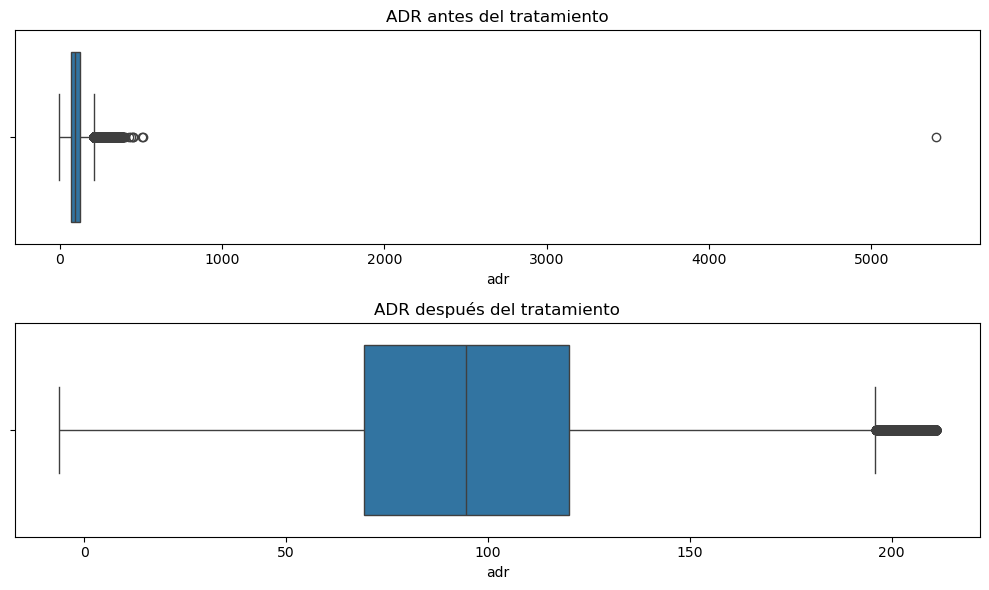

In [16]:
# comparación de distribuciones antes y después del tratamiento
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sns.boxplot(
    x=df_prep['adr'],
    ax=ax[0]
)
ax[0].set_title('ADR antes del tratamiento')
sns.boxplot(
    x=df_out['adr'],
    ax=ax[1]
)
ax[1].set_title('ADR después del tratamiento')
plt.tight_layout()
plt.show()

El boxplot evidencia que la variable ADR presentaba numerosos valores atípicos, incluyendo observaciones extremadamente altas que distorsionaban su distribución. Tras el tratamiento de outliers, la distribución se vuelve más compacta y representativa del comportamiento general de los datos, reduciendo significativamente la influencia de valores extremos sobre los análisis posteriores.

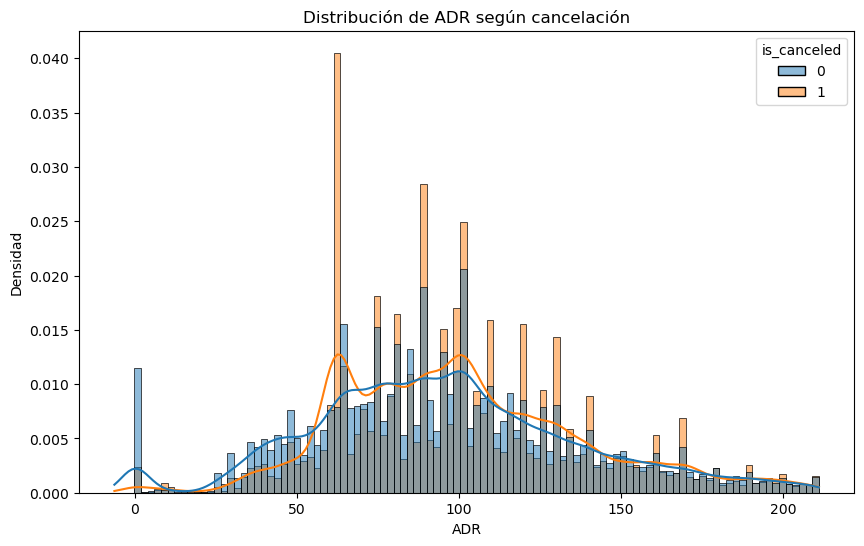

In [17]:
# distribución de ADR después del tratamiento
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_out,
    x='adr',
    hue='is_canceled',
    kde=True,
    stat='density',
    common_norm=False
)
plt.title('Distribución de ADR según cancelación')
plt.xlabel('ADR')
plt.ylabel('Densidad')
plt.show()

Las distribuciones de ADR para reservas canceladas y no canceladas presentan un alto grado de solapamiento. No obstante, las reservas canceladas muestran una mayor concentración en valores de ADR elevados, sugiriendo que tarifas más altas podrían asociarse con una mayor probabilidad de cancelación.

### d. Transforma las variables categóricas en variables dummies, estandariza las variables independientes con media igual a cero y desviación estándar 1 y realiza una división de los datos para entrenamiento y test, este último con un 33% de registros.

In [18]:
# Separamos las variables predictoras (X)
# de la variable objetivo (y).
X = df_out.drop(columns=['is_canceled'])
y = df_out['is_canceled']

In [19]:
# Transformamos las variables categóricas en variables dummy
# para que puedan ser utilizadas por los modelos de Machine Learning.
# drop_first=True evita la multicolinealidad eliminando una categoría
# de referencia por cada variable categórica.
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)
# Mostramos las dimensiones finales del conjunto de variables predictoras
# después de la transformación.
print("Dimensiones después de dummies:", X.shape)

Dimensiones después de dummies: (119383, 67)


In [20]:
# Dividimos el conjunto de datos en entrenamiento y prueba.
# El 67% de los registros se utilizará para entrenar los modelos
# y el 33% restante para evaluar su desempeño.

# Se utiliza stratify=y para mantener la misma proporción de
# reservas canceladas y no canceladas en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)
# Mostramos las dimensiones de los conjuntos generados
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (79986, 67)
X_test : (39397, 67)
y_train: (79986,)
y_test : (39397,)


In [21]:
# Estandarizamos las variables predictoras utilizando StandardScaler.
# Este proceso transforma cada variable para que tenga una media
# cercana a 0 y una desviación estándar cercana a 1.
scaler = StandardScaler()
# Ajustamos el escalador utilizando únicamente los datos de entrenamiento
# y transformamos dichos datos.
X_train_scaled = scaler.fit_transform(X_train)
# Aplicamos la misma transformación al conjunto de prueba
# utilizando los parámetros calculados en entrenamiento.
X_test_scaled = scaler.transform(X_test)
# Verificamos que la estandarización se haya realizado correctamente.
# Después de aplicar StandardScaler, la media de las variables
# debería ser cercana a 0 y la desviación estándar cercana a 1.
print("Media aproximada:", X_train_scaled.mean().round(4))
print("Desviación estándar aproximada:", X_train_scaled.std().round(4))

Media aproximada: -0.0
Desviación estándar aproximada: 0.9925


Las variables categóricas fueron transformadas mediante variables dummy, obteniéndose un conjunto de 67 variables predictoras. Posteriormente, los datos fueron divididos en entrenamiento (67%) y prueba (33%) utilizando estratificación sobre la variable objetivo. Finalmente, las variables independientes fueron estandarizadas con StandardScaler, obteniendo una media cercana a cero y una desviación estándar cercana a uno, condición adecuada para el entrenamiento de modelos de redes neuronales.

### 3. Implementa dos modelos de red neuronal multicapa, considerando las siguientes características.

a. Cada modelo debe contar con tres capas ocultas.

b. El primer modelo debe tener funciones de activación tanh, relu y tanh en las capas ocultas, mientras que el segundo sólo funciones tanh en sus capas ocultas.

c. Cada modelo debe tener un mínimo de 20 neuronas para cada capa oculta.
Use un optimizador SGD, con 10 épocas de entrenamiento; cada capa deberá
tener una neurona de sesgo. Debes decidir cómo se inicializan los pesos y el sesgo en cada capa oculta y de salida. Muestra los resultados en un gráfico que tendrá una curva de accuracy para cada modelo en cada época de entrenamiento. Cada modelo debe lograr un accuracy superior al 75%. Concluye de acuerdo a los resultados.


In [22]:
# Cantidad de variables predictoras
n_inputs = X_train_scaled.shape[1]
# Revisamos cantidad de variables de entrada 
print("Cantidad de variables de entrada:", n_inputs)

Cantidad de variables de entrada: 67


### Modelo 1

In [23]:
# Modelo 1: activaciones tanh, relu y tanh
modelo_1 = keras.Sequential()

# Primera capa oculta con activación tanh
modelo_1.add(
    Dense(
        units=20,
        activation='tanh',
        input_shape=(n_inputs,),
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Segunda capa oculta con activación relu
modelo_1.add(
    Dense(
        units=20,
        activation='relu',
        kernel_initializer='he_normal',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Tercera capa oculta con activación tanh
modelo_1.add(
    Dense(
        units=20,
        activation='tanh',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Capa de salida para clasificación binaria
modelo_1.add(
    Dense(
        units=1,
        activation='sigmoid',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Compilamos el modelo con SGD
modelo_1.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │         1,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,221 (8.68 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

El modelo fue diseñado con tres capas ocultas de 20 neuronas y activaciones tanh-ReLU-tanh. La red posee 2.221 parámetros entrenables e incluye sesgos en todas sus capas, cumpliendo las especificaciones del desafío para la clasificación de reservas canceladas y no canceladas.

In [24]:
# Entrenamos el modelo 1
history_1 = modelo_1.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7624 - loss: 0.4935 - val_accuracy: 0.7971 - val_loss: 0.4416
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8038 - loss: 0.4243 - val_accuracy: 0.8070 - val_loss: 0.4185
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8104 - loss: 0.4083 - val_accuracy: 0.8109 - val_loss: 0.4072
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8134 - loss: 0.3997 - val_accuracy: 0.8150 - val_loss: 0.4004
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8166 - loss: 0.3937 - val_accuracy: 0.8178 - val_loss: 0.3957
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8187 - loss: 0.3894 - val_accuracy: 0.8194 - val_loss: 0.3925
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8211 - loss: 0.3862 - val_accuracy: 0.8205 - val_loss: 0.3902
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8227 - loss: 0.3838 - 

El Modelo 1 presentó una evolución estable durante el entrenamiento, incrementando su accuracy desde 76.24% hasta 82.48% y reduciendo progresivamente la pérdida. Esto indica que la red aprendió adecuadamente los patrones asociados a la cancelación de reservas sin evidenciar problemas importantes de entrenamiento.

In [25]:
# Mostramos el accuracy obtenido durante la última época
# de entrenamiento y validación del Modelo 1. 
print("Train Accuracy Modelo 1:", history_1.history['accuracy'][-1])
print("Validation Accuracy Modelo 1:", history_1.history['val_accuracy'][-1])

# Evaluamos el modelo 1 utilizando el conjunto de prueba
# para medir su capacidad de generalización.
loss_1, acc_1 = modelo_1.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)
print("Test Accuracy Modelo 1:", round(acc_1, 4))

Train Accuracy Modelo 1: 0.8247568607330322
Validation Accuracy Modelo 1: 0.8247582316398621
Test Accuracy Modelo 1: 0.8248


El Modelo 1 obtuvo un accuracy de 82.47% en entrenamiento y 82.48% en validación y prueba. La cercanía entre estos valores sugiere un buen ajuste del modelo y una adecuada capacidad para generalizar sobre datos no vistos.

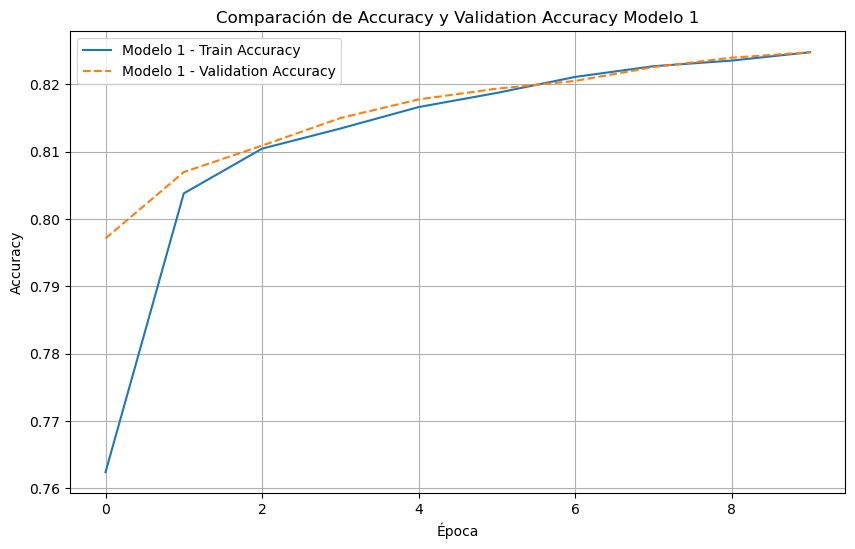

In [26]:
# Graficamos la evolución del accuracy de entrenamiento y validación
# del Modelo 1 a lo largo de las 10 épocas de entrenamiento.
plt.figure(figsize=(10, 6))

# Modelo 1 Accuracy obtenido sobre los datos de entrenamiento
plt.plot(
    history_1.history['accuracy'],
    label='Modelo 1 - Train Accuracy'
)
# Accuracy obtenido sobre los datos de validación
plt.plot(
    history_1.history['val_accuracy'],
    linestyle='--',
    label='Modelo 1 - Validation Accuracy'
)
plt.title('Comparación de Accuracy y Validation Accuracy Modelo 1')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

Las curvas de accuracy y validation accuracy presentan un comportamiento muy similar y convergen alrededor del 82%, lo que sugiere que el modelo aprende de forma estable y posee una buena capacidad de generalización sin señales importantes de sobreajuste.

### Modelo 2

In [27]:
# Modelo 2: activaciones tanh, tanh y tanh
modelo_2 = keras.Sequential()

# Primera capa oculta con activación tanh
modelo_2.add(
    Dense(
        units=20,
        activation='tanh',
        input_shape=(n_inputs,),
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Segunda capa oculta con activación tanh
modelo_2.add(
    Dense(
        units=20,
        activation='tanh',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Tercera capa oculta con activación tanh
modelo_2.add(
    Dense(
        units=20,
        activation='tanh',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Capa de salida para clasificación binaria
modelo_2.add(
    Dense(
        units=1,
        activation='sigmoid',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        use_bias=True
    )
)

# Compilamos el modelo con SGD
modelo_2.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 20)             │         1,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,221 (8.68 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

El modelo fue diseñado con tres capas ocultas de 20 neuronas y activaciones tanh en todas ellas. La arquitectura posee 2.221 parámetros entrenables e incluye sesgos en cada capa, cumpliendo las especificaciones definidas para la clasificación de reservas canceladas y no canceladas.

In [28]:
# Entrenamos el modelo 2
history_2 = modelo_2.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7789 - loss: 0.4735 - val_accuracy: 0.8010 - val_loss: 0.4354
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8041 - loss: 0.4225 - val_accuracy: 0.8064 - val_loss: 0.4181
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8097 - loss: 0.4097 - val_accuracy: 0.8091 - val_loss: 0.4089
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8122 - loss: 0.4022 - val_accuracy: 0.8124 - val_loss: 0.4028
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8144 - loss: 0.3970 - val_accuracy: 0.8131 - val_loss: 0.3987
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8162 - loss: 0.3933 - val_accuracy: 0.8140 - val_loss: 0.3957
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8176 - loss: 0.3904 - val_accuracy: 0.8158 - val_loss: 0.3935
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8193 - loss: 0.3881 - 

El Modelo 2 presentó una mejora continua durante el entrenamiento, incrementando su accuracy desde 77.89% hasta 82.22% y reduciendo gradualmente la pérdida. El comportamiento similar entre entrenamiento y validación sugiere que la red aprendió de manera estable sin evidenciar problemas importantes de sobreajuste.

In [29]:
# Mostramos el accuracy obtenido durante la última época
# de entrenamiento y validación del Modelo 2.
print("Train Accuracy Modelo 2:", history_2.history['accuracy'][-1])
print("Validation Accuracy Modelo 2:", history_2.history['val_accuracy'][-1])

# Evaluamos el modelo utilizando el conjunto de prueba
# para medir su capacidad de generalización.
loss_2, acc_2 = modelo_2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Accuracy Modelo 2:", round(acc_2, 4))

Train Accuracy Modelo 2: 0.8222188949584961
Validation Accuracy Modelo 2: 0.8176764845848083
Test Accuracy Modelo 2: 0.8177


El Modelo 2 obtuvo un accuracy de 82.22% en entrenamiento y 81.77% en validación y prueba. La cercanía entre estos valores evidencia un buen comportamiento predictivo y una adecuada capacidad para generalizar sobre datos no observados durante el entrenamiento.

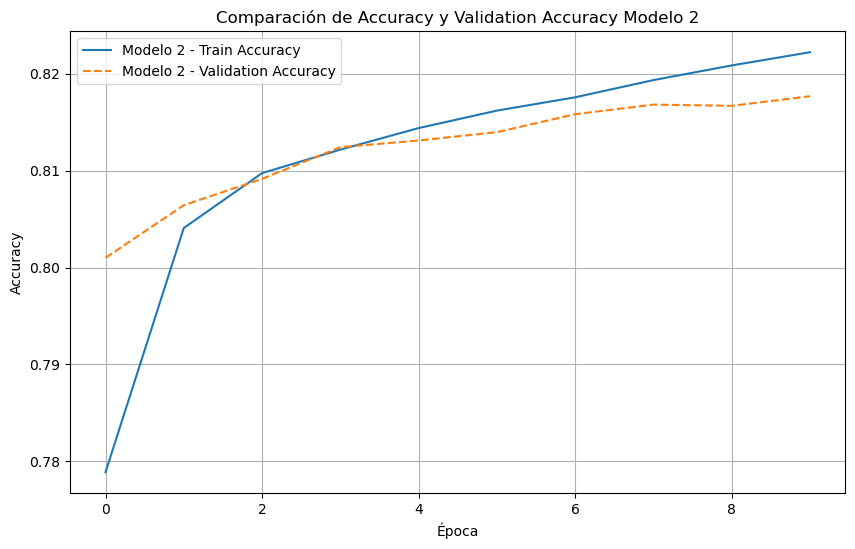

In [30]:
# Graficamos la evolución del accuracy de entrenamiento y validación
# del Modelo 2 a lo largo de las 10 épocas de entrenamiento.
plt.figure(figsize=(10, 6))

# Modelo 2 Accuracy obtenido sobre los datos de entrenamiento
plt.plot(
    history_2.history['accuracy'],
    label='Modelo 2 - Train Accuracy'
)
# Accuracy obtenido sobre los datos de validación
plt.plot(
    history_2.history['val_accuracy'],
    linestyle='--',
    label='Modelo 2 - Validation Accuracy'
)
plt.title('Comparación de Accuracy y Validation Accuracy Modelo 2')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

Las curvas de entrenamiento y validación muestran un comportamiento estable y convergente, alcanzando valores cercanos al 82% de accuracy. La reducida diferencia entre ambas métricas sugiere una buena capacidad de generalización y ausencia de sobreajuste significativo.

### Comparacion de accuracy de ambos modelos 

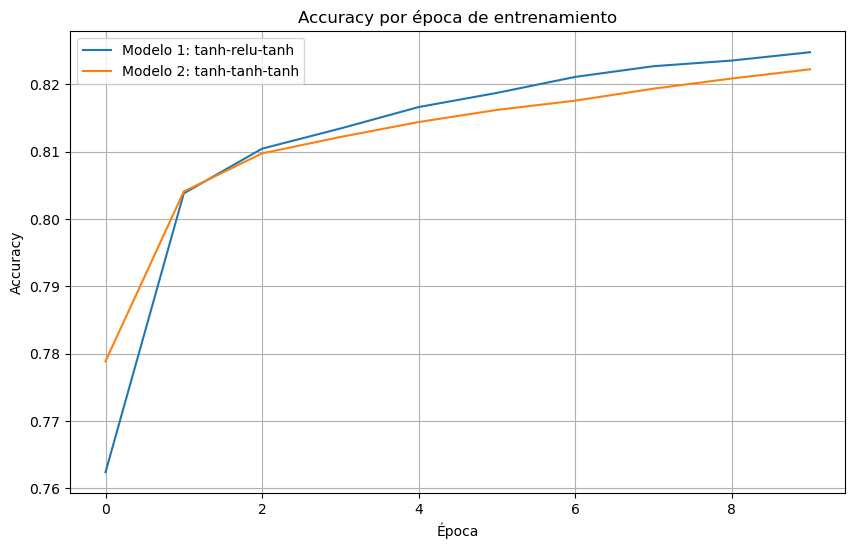

In [31]:
# Comparamos la evolución del accuracy de entrenamiento
# entre ambos modelos de red neuronal para identificar
# cuál de las arquitecturas presenta un mejor desempeño.
plt.figure(figsize=(10, 6))
# Accuracy del Modelo 1 (tanh-relu-tanh)
plt.plot(
    history_1.history['accuracy'],
    label='Modelo 1: tanh-relu-tanh'
)
# Accuracy del Modelo 2 (tanh-tanh-tanh)
plt.plot(
    history_2.history['accuracy'],
    label='Modelo 2: tanh-tanh-tanh'
)
plt.title('Accuracy por época de entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

Conclusión: Ambos modelos muestran una evolución estable y alcanzan accuracies superiores al 82%. No obstante, el Modelo 1 presenta un desempeño ligeramente superior durante todo el entrenamiento, obteniendo finalmente mejores resultados que el Modelo 2. Por esta razón, el Modelo 1 se considera la mejor alternativa para la predicción de cancelación de reservas.

### 4. Construye una red neuronal con regularización Dropout aplicando búsqueda de grilla para tres fold. El modelo debe conseguir un accuracy superior al 80%. La búsqueda debe sintonizar los siguientes hiper parámetros:

a. Cantidad de capas ocultas: de 3 o 4

b. Método de optimización: Adam o SGD

c. learning_rate: 0.03 y 0.06

d. Cantidad de neuronas en las capas ocultas: 20

e. Funciones de activación en las capas ocultas: tanh

f. Rate para Dropout: 0.001

g. Inicialización de los pesos: [glorot_normal, glorot_uniform]

In [32]:
# Función que construye una red neuronal multicapa.
# Permite modificar distintos hiperparámetros para ser
# evaluados posteriormente mediante Grid Search.
def crear_modelo(
    hidden_layers=3,
    optimizer='adam',
    learning_rate=0.03,
    initializer='glorot_uniform'
):
    # Inicializamos la red neuronal secuencial
    model = keras.Sequential()

    # Primera capa oculta con 20 neuronas y activación tanh
    model.add(Dense(
        20,
        activation='tanh',
        kernel_initializer=initializer,
        bias_initializer='zeros',
        input_shape=(n_inputs,)
    ))
    # Regularización Dropout para reducir el riesgo de sobreajuste
    model.add(Dropout(0.001))

    # Agregamos las capas ocultas restantes según el hiperparámetro
    # hidden_layers seleccionado por Grid Search
    for _ in range(hidden_layers - 1):
        model.add(Dense(
            20,
            activation='tanh',
            kernel_initializer=initializer,
            bias_initializer='zeros'
        ))
        model.add(Dropout(0.001))

    # Capa de salida para clasificación binaria
    model.add(Dense(
        1,
        activation='sigmoid',
        kernel_initializer=initializer,
        bias_initializer='zeros'
    ))

    # Seleccionamos el optimizador definido por Grid Search
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)
    # Compilamos el modelo
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [33]:
# Creamos un wrapper de SciKeras que permite integrar
# el modelo de TensorFlow/Keras con las herramientas
# de validación cruzada y Grid Search de Scikit-Learn.
modelo_grid = KerasClassifier(
    model=crear_modelo,
    hidden_layers=3,
    optimizer='adam',
    learning_rate=0.03,
    initializer='glorot_uniform',
    # Configuración de entrenamiento
    epochs=10,
    batch_size=32,
    # Muestra información del progreso de ejecución
    verbose=1
)

In [34]:
# Definimos la grilla de hiperparámetros que será evaluada
# mediante Grid Search con validación cruzada de 3 folds.
param_grid = {
    # Cantidad de capas ocultas a evaluar
    'model__hidden_layers': [3, 4],
    # Optimizadores a comparar
    'model__optimizer': ['adam', 'sgd'],
    # Tasas de aprendizaje a evaluar
    'model__learning_rate': [0.03, 0.06],
    # Métodos de inicialización de pesos
    'model__initializer': ['glorot_normal', 'glorot_uniform']
}

In [35]:
# Configuramos Grid Search para evaluar todas las combinaciones
# de hiperparámetros definidas anteriormente.
grid = GridSearchCV(
    # Modelo base que será optimizado
    estimator=modelo_grid,
    # Grilla de hiperparámetros a evaluar
    param_grid=param_grid,
    # Métrica utilizada para comparar los modelos
    scoring='accuracy',
    # Validación cruzada de 3 folds
    cv=3,
    # Utiliza todos los núcleos disponibles del procesador
    n_jobs=-1,
    # Muestra información del progreso de ejecución
    verbose=1
)
# Ejecutamos la búsqueda de hiperparámetros utilizando
# el conjunto de entrenamiento previamente escalado.
grid.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7966 - loss: 0.4337
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8132 - loss: 0.3992
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8182 - loss: 0.3902
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8209 - loss: 0.3849
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8228 - loss: 0.3807
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8244 - loss: 0.3769
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8261 - loss: 0.3738
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8274 - loss: 0.3712
Epoch 9/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8291 - loss: 0.3689
Epoch 10/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8303 - loss: 0.3668


GridSearchCV(cv=3,
             estimator=KerasClassifier(batch_size=32, epochs=10, hidden_layers=3, initializer='glorot_uniform', learning_rate=0.03, model=<function crear_modelo at 0x00000207B1A327A0>, optimizer='adam'),
             n_jobs=-1,
             param_grid={'model__hidden_layers': [3, 4],
                         'model__initializer': ['glorot_normal',
                                                'glorot_uniform'],
                         'model__learning_rate': [0.03, 0.06],
                         'model__optimizer': ['adam', 'sgd']},
             scoring='accuracy', verbose=1)

In [36]:
# Mostramos la mejor combinación de hiperparámetros
# encontrada por Grid Search.
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)
# Mostramos el mejor accuracy promedio obtenido
# durante la validación cruzada de 3 folds.
print("Mejor accuracy CV:")
print(round(grid.best_score_, 4))

Mejores hiperparámetros encontrados:
{'model__hidden_layers': 4, 'model__initializer': 'glorot_normal', 'model__learning_rate': 0.06, 'model__optimizer': 'sgd'}
Mejor accuracy CV:
0.8231


Se realizó una búsqueda exhaustiva de hiperparámetros mediante Grid Search utilizando validación cruzada de 3 folds. Se evaluaron 16 combinaciones distintas considerando número de capas ocultas, optimizador, tasa de aprendizaje e inicialización de pesos. La mejor configuración correspondió a una red neuronal con 4 capas ocultas, optimizador SGD, learning rate de 0.06 e inicialización Glorot Normal, alcanzando un accuracy promedio de validación cruzada de 82.31%, superando ampliamente el mínimo de 80% solicitado.

### Utilizando los mejores parametros 

In [37]:
# Recuperamos el mejor modelo encontrado por Grid Search,
# es decir, la combinación de hiperparámetros que obtuvo
# el mayor accuracy promedio durante la validación cruzada.
best_model = grid.best_estimator_

# Realizamos predicciones sobre el conjunto de prueba.
y_pred_best = best_model.predict(X_test_scaled)

# Obtenemos las probabilidades estimadas para la clase positiva
# (reserva cancelada), necesarias para calcular la curva ROC y el AUC.
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculamos el accuracy final sobre el conjunto de prueba.
print("Accuracy test:", round(accuracy_score(y_test, y_pred_best), 4))

# Mostramos las métricas de clasificación:
# precision, recall, f1-score y soporte para cada clase.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Mostramos la matriz de confusión para analizar
# los aciertos y errores de clasificación.
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_best))

1232/1232 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy test: 0.8272

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     24805
           1       0.83      0.68      0.74     14592

    accuracy                           0.83     39397
   macro avg       0.83      0.80      0.81     39397
weighted avg       0.83      0.83      0.82     39397


Matriz de confusión:
[[22723  2082]
 [ 4724  9868]]


AUC: 0.8937


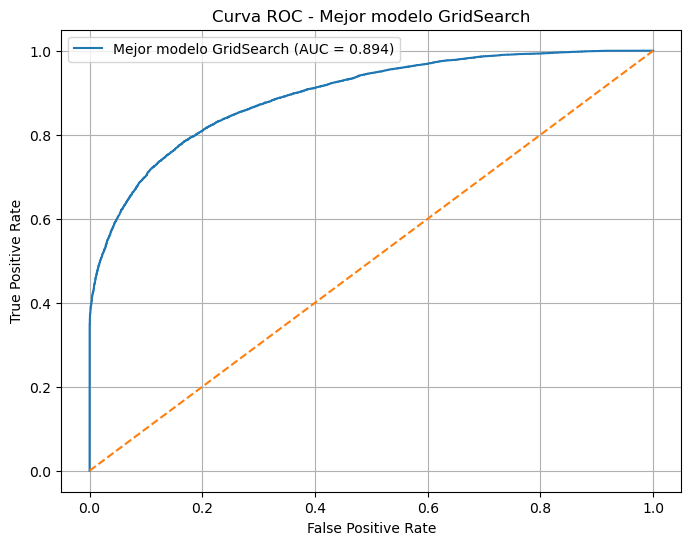

In [38]:
# Calculamos los puntos necesarios para construir la curva ROC,
# incluyendo la tasa de falsos positivos (FPR), la tasa de
# verdaderos positivos (TPR) y los distintos umbrales evaluados.
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)

# Calculamos el área bajo la curva ROC (AUC),
# que mide la capacidad del modelo para diferenciar
# entre reservas canceladas y no canceladas.
auc_best = roc_auc_score(y_test, y_proba_best)
print("AUC:", round(auc_best, 4))

# Graficamos la curva ROC del mejor modelo obtenido.
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f'Mejor modelo GridSearch (AUC = {auc_best:.3f})'
)

# Línea de referencia que representa una clasificación aleatoria.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)
plt.title('Curva ROC - Mejor modelo GridSearch')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

El mejor modelo obtenido mediante Grid Search alcanzó un accuracy de 82.72% en el conjunto de test, superando el mínimo de 80% solicitado. Además, obtuvo un AUC de 0.894, lo que indica una buena capacidad para distinguir entre reservas canceladas y no canceladas.

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de las reservas no canceladas y también logra identificar una proporción relevante de reservas canceladas. Sin embargo, el recall de la clase 1 es menor que el de la clase 0, lo que indica que aún existen cancelaciones que el modelo no detecta completamente. Aun así, el desempeño general es sólido y cumple con los requisitos del desafío.

### 5. Del conjunto original (sin los valores excluidos) escoge al azar cinco observaciones en que “deposit_type_Non Refund” sea cero, y con esto realiza una predicción usando el mejor modelo encontrado por la búsqueda de grilla anterior. Comenta los resultados.

In [39]:
# Seleccionamos aleatoriamente 5 observaciones desde la base de datos original
# (data bruta), considerando únicamente aquellas reservas cuyo tipo de
# depósito no corresponde a "Non Refund".
muestra_bruta = df[
    df['deposit_type'] != 'Non Refund'
].sample(
    5,
    random_state= RANDOM_STATE
)
# Mostramos las observaciones seleccionadas
display(muestra_bruta)

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
23710,23710,Resort Hotel,0,197,2016,April,18,30,1,1,...,No Deposit,298.0,NaN,0,Transient-Party,54.50,0,0,Check-Out,02-05-16
21864,21864,Resort Hotel,0,5,2016,March,11,9,0,3,...,No Deposit,240.0,NaN,0,Transient-Party,109.00,1,0,Check-Out,12-03-16
100870,100870,City Hotel,0,200,2016,October,45,31,1,2,...,No Deposit,9.0,NaN,0,Transient,82.92,0,3,Check-Out,03-11-16
2453,2453,Resort Hotel,0,0,2015,October,42,16,2,2,...,No Deposit,240.0,NaN,0,Transient,57.83,1,0,Check-Out,20-10-15
108007,108007,City Hotel,0,98,2017,March,11,14,2,5,...,No Deposit,27.0,NaN,0,Transient,68.00,0,0,Check-Out,21-03-17


In [40]:
# Aplicamos a las observaciones seleccionadas el mismo
# preprocesamiento utilizado durante el entrenamiento del modelo.
# Eliminamos las variables descartadas previamente durante
# la etapa de limpieza y preparación de datos.
muestra_modelo = muestra_bruta.drop(
    columns=[
        'index',
        'arrival_date_year',
        'agent',
        'country',
        'company',
        'reservation_status',
        'reservation_status_date',
        'is_canceled'
    ],
    errors='ignore'
)
# Transformamos las variables categóricas en variables dummy
# para que tengan el mismo formato utilizado por la red neuronal.
muestra_modelo = pd.get_dummies(
    muestra_modelo,
    drop_first=True,
    dtype=int
)
# Alineamos las columnas con las utilizadas durante el entrenamiento,
# agregando aquellas que no existan en la muestra con valor cero.
muestra_modelo = muestra_modelo.reindex(
    columns=X.columns,
    fill_value=0
)
# Verificamos las dimensiones finales de la muestra preparada
# para ser utilizada por el modelo.
print(muestra_modelo.shape)

(5, 67)


In [41]:
# Aplicamos la misma estandarización utilizada durante el entrenamiento
# para que las nuevas observaciones tengan la misma escala que los datos
# usados por la red neuronal.
muestra_scaled = scaler.transform(
    muestra_modelo
)

# Utilizamos el mejor modelo encontrado mediante Grid Search
# para generar las predicciones sobre las observaciones seleccionadas.
predicciones = best_model.predict(
    muestra_scaled
)
# Obtenemos la probabilidad estimada de cancelación para cada reserva.
probabilidades = best_model.predict_proba(
    muestra_scaled
)[:,1]

# Construimos una tabla con los resultados obtenidos.
resultado = muestra_bruta.copy()
resultado['Probabilidad_Cancelacion'] = (
    probabilidades.round(4)
)
resultado['Prediccion'] = predicciones

# Mostramos las variables más relevantes junto con las predicciones
# realizadas por el modelo.
display(
    resultado[
        [
            'hotel',
            'deposit_type',
            'adr',
            'lead_time',
            'Probabilidad_Cancelacion',
            'Prediccion'
        ]
    ]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,hotel,deposit_type,adr,lead_time,Probabilidad_Cancelacion,Prediccion
23710,Resort Hotel,No Deposit,54.50,197,0.0771,0
21864,Resort Hotel,No Deposit,109.00,5,0.0086,0
100870,City Hotel,No Deposit,82.92,200,0.2940,0
2453,Resort Hotel,No Deposit,57.83,0,0.0036,0
108007,City Hotel,No Deposit,68.00,98,0.4371,0


Se seleccionaron aleatoriamente cinco observaciones desde la base de datos original cumpliendo la condición de que el tipo de depósito no correspondiera a "Non Refund". Posteriormente, las observaciones fueron transformadas mediante el mismo preprocesamiento utilizado durante el entrenamiento del modelo y evaluadas utilizando la mejor red neuronal obtenida mediante búsqueda de grilla.

Los resultados muestran que las cinco reservas fueron clasificadas como no canceladas. Las probabilidades de cancelación obtenidas oscilaron entre 0.07% y 43.71%, todas por debajo del umbral de decisión del modelo. La mayor probabilidad correspondió a una reserva de City Hotel con un lead time de 98 días, lo que indica un mayor riesgo relativo de cancelación respecto de las demás observaciones, aunque no suficiente para ser clasificada como cancelada.

El mejor modelo obtenido mediante Grid Search logró realizar predicciones consistentes sobre observaciones seleccionadas desde la base de datos original. Todas las reservas analizadas correspondían a clientes con tipo de depósito "No Deposit", y el modelo estimó probabilidades de cancelación relativamente bajas, clasificándolas como reservas no canceladas. Esto evidencia que la red neuronal utiliza la información conjunta de múltiples variables para evaluar el riesgo de cancelación y no depende exclusivamente del tipo de depósito para tomar sus decisiones.